In [2]:
import numpy as np
import re
import os

import tensorflow as tf
import tensorflow.keras.backend as K
#! pip install tensorflow_addons
import tensorflow_addons as tfa
import tensorflow_datasets as tfds
from tensorflow import keras
from tensorflow.keras import layers, losses

import matplotlib.pylab as plt
import tqdm

In [3]:
def load_dataset(filenames, labeled=True, ordered=False, autotune=tf.data.experimental.AUTOTUNE):
    dataset = tf.data.TFRecordDataset(filenames)
    dataset = dataset.map(read_tfrecord, num_parallel_calls=autotune)
    return dataset

def decode_image(image, img_size=[256,256,3]):
    image = tf.image.decode_jpeg(image, channels=3)
    image = (tf.cast(image, tf.float32) / 127.5) - 1        
    image = tf.reshape(image, img_size)             
    return image

def read_tfrecord(example):
    tfrecord_format = {
        "image_name": tf.io.FixedLenFeature([], tf.string),
        "image":      tf.io.FixedLenFeature([], tf.string),
        "target":     tf.io.FixedLenFeature([], tf.string)
    }
    example = tf.io.parse_single_example(example, tfrecord_format)  
    image = decode_image(example['image'])    
    return image

def count_data_items(filenames):
    n = [int(re.compile(r"-([0-9]*)\.").search(filename).group(1)) for filename in filenames]
    return np.sum(n)

batch_size = 32

data_path = '../input/gan-getting-started'
monet_filenames = tf.io.gfile.glob(str(os.path.join(data_path, 'monet_tfrec', '*.tfrec')))
photo_filenames = tf.io.gfile.glob(str(os.path.join(data_path, 'photo_tfrec', '*.tfrec')))

monet_ds = load_dataset(monet_filenames)
photo_ds = load_dataset(photo_filenames)

n_monet_samples = count_data_items(monet_filenames)
n_photo_samples = count_data_items(photo_filenames)
dataset = tf.data.Dataset.zip((monet_ds, photo_ds))

In [4]:
dataset_to_numpy = list(monet_ds.as_numpy_iterator())
shape = tf.shape(dataset_to_numpy)
print(shape)
tf.data.experimental.cardinality(dataset)

tf.Tensor([300 256 256   3], shape=(4,), dtype=int32)


<tf.Tensor: shape=(), dtype=int64, numpy=-2>

In [5]:
class CycleGAN(keras.Model):
    def __init__(
        self,
        monet_generator,
        photo_generator,
        monet_discriminator,
        photo_discriminator,
        lambda_cycle=10,
    ):
        super(CycleGAN, self).__init__()
        self.m_gen = monet_generator
        self.p_gen = photo_generator
        self.m_disc = monet_discriminator
        self.p_disc = photo_discriminator
        self.lambda_cycle = lambda_cycle
        
    def compile(
        self,
        m_gen_optimizer,
        p_gen_optimizer,
        m_disc_optimizer,
        p_disc_optimizer,
        gen_loss_fn,
        disc_loss_fn,
        cycle_loss_fn,
        identity_loss_fn
    ):
        super(CycleGAN, self).compile()
        self.m_gen_optimizer = m_gen_optimizer
        self.p_gen_optimizer = p_gen_optimizer
        self.m_disc_optimizer = m_disc_optimizer
        self.p_disc_optimizer = p_disc_optimizer
        self.gen_loss_fn = gen_loss_fn
        self.disc_loss_fn = disc_loss_fn
        self.cycle_loss_fn = cycle_loss_fn
        self.identity_loss_fn = identity_loss_fn

    def generate(self, image):
        return self.m_gen(tf.expand_dims(image, axis=0), training=False)

    def load(
        self, 
        filepath
    ):
        self.m_gen.load_weights(filepath.replace('model_name', 'm_gen'), by_name=True)
        self.p_gen.load_weights(filepath.replace('model_name', 'p_gen'), by_name=True)
        self.m_disc.load_weights(filepath.replace('model_name', 'm_disc'), by_name=True)
        self.p_disc.load_weights(filepath.replace('model_name', 'p_disc'), by_name=True)

    def save(
        self, 
        filepath
    ):
        self.m_gen.save(filepath.replace('model_name', 'm_gen'))
        self.p_gen.save(filepath.replace('model_name', 'p_gen'))
        self.m_disc.save(filepath.replace('model_name', 'm_disc'))
        self.p_disc.save(filepath.replace('model_name', 'p_disc'))

        
    def train_step(self, batch_data):
        real_monet, real_photo = batch_data
        
        with tf.GradientTape(persistent=True) as tape:
            # photo to monet back to photo
            real_photo = tf.expand_dims(real_photo, axis=0)
            real_monet = tf.expand_dims(real_monet, axis=0)

            fake_monet = self.m_gen(real_photo, training=True)
            cycled_photo = self.p_gen(fake_monet, training=True)

            # monet to photo back to monet
            fake_photo = self.p_gen(real_monet, training=True)
            cycled_monet = self.m_gen(fake_photo, training=True)

            # generating itself
            same_monet = self.m_gen(real_monet, training=True)
            same_photo = self.p_gen(real_photo, training=True)

            # discriminator used to check, inputing real images
            disc_real_monet = self.m_disc(real_monet, training=True)
            disc_real_photo = self.p_disc(real_photo, training=True)

            # discriminator used to check, inputing fake images
            disc_fake_monet = self.m_disc(fake_monet, training=True)
            disc_fake_photo = self.p_disc(fake_photo, training=True)

            # evaluates generator loss
            monet_gen_loss = self.gen_loss_fn(disc_fake_monet)
            photo_gen_loss = self.gen_loss_fn(disc_fake_photo)

            # evaluates total cycle consistency loss
            total_cycle_loss = self.cycle_loss_fn(real_monet, cycled_monet, self.lambda_cycle) + self.cycle_loss_fn(real_photo, cycled_photo, self.lambda_cycle)

            # evaluates total generator loss
            total_monet_gen_loss = monet_gen_loss + total_cycle_loss + self.identity_loss_fn(real_monet, same_monet, self.lambda_cycle)
            total_photo_gen_loss = photo_gen_loss + total_cycle_loss + self.identity_loss_fn(real_photo, same_photo, self.lambda_cycle)

            # evaluates discriminator loss
            monet_disc_loss = self.disc_loss_fn(disc_real_monet, disc_fake_monet)
            photo_disc_loss = self.disc_loss_fn(disc_real_photo, disc_fake_photo)

        # Calculate the gradients for generator and discriminator
        monet_generator_gradients = tape.gradient(total_monet_gen_loss, self.m_gen.trainable_variables)
        photo_generator_gradients = tape.gradient(total_photo_gen_loss, self.p_gen.trainable_variables)
        monet_discriminator_gradients = tape.gradient(monet_disc_loss, self.m_disc.trainable_variables)
        photo_discriminator_gradients = tape.gradient(photo_disc_loss, self.p_disc.trainable_variables)

        # Apply the gradients to the optimizer
        self.m_gen_optimizer.apply_gradients(zip(monet_generator_gradients, self.m_gen.trainable_variables))
        self.p_gen_optimizer.apply_gradients(zip(photo_generator_gradients, self.p_gen.trainable_variables))
        self.m_disc_optimizer.apply_gradients(zip(monet_discriminator_gradients, self.m_disc.trainable_variables))
        self.p_disc_optimizer.apply_gradients(zip(photo_discriminator_gradients, self.p_disc.trainable_variables))
        
        total_loss = total_monet_gen_loss + total_photo_gen_loss + monet_disc_loss + photo_disc_loss

        return {
            "total_loss": total_loss,
            "monet_gen_loss": total_monet_gen_loss,
            "photo_gen_loss": total_photo_gen_loss,
            "monet_disc_loss": monet_disc_loss,
            "photo_disc_loss": photo_disc_loss
        }


def Generator(img_shape=[256, 256, 3]):
    inputs = layers.Input(shape=img_shape)
    down_stack = [
        downsample(64, 4, apply_instancenorm=False),
        downsample(128, 4),
        downsample(256, 4),
        downsample(512, 4),
        downsample(512, 4),
        downsample(512, 4),
        downsample(512, 4),
        downsample(512, 4),
    ]
    up_stack = [
        upsample(512, 4, apply_dropout=True),
        upsample(512, 4, apply_dropout=True),
        upsample(512, 4, apply_dropout=True),
        upsample(512, 4),
        upsample(256, 4),
        upsample(128, 4),
        upsample(64, 4),
    ]

    initializer = tf.random_normal_initializer(0., 0.02)
    last = layers.Conv2DTranspose(3, 4, strides=2, padding='same', kernel_initializer=initializer, activation='tanh')

    x = inputs
    skips = []
    for down in down_stack:
        x = down(x)
        skips.append(x)
    skips = reversed(skips[:-1])

    for up, skip in zip(up_stack, skips):
        x = up(x)
        x = layers.Concatenate()([x, skip])
    x = last(x)
    return keras.Model(inputs=inputs, outputs=x)


def Discriminator(img_shape=[256, 256, 3]):
    initializer = tf.random_normal_initializer(0., 0.02)
    gamma_init = keras.initializers.RandomNormal(mean=0.0, stddev=0.02)

    inp = layers.Input(shape=img_shape, name='input_image')
    x = inp

    x = downsample(64, 4, False)(x) 
    x = downsample(128, 4)(x) 
    x = downsample(256, 4)(x) 

    x = layers.ZeroPadding2D()(x) 
    x = layers.Conv2D(512, 4, strides=1, kernel_initializer=initializer, use_bias=False)(x) 
    x = tfa.layers.InstanceNormalization(gamma_initializer=gamma_init)(x)
    x = layers.LeakyReLU()(x)
    x = layers.ZeroPadding2D()(x) 
    x = layers.Conv2D(1, 4, strides=1, kernel_initializer=initializer)(x) 

    return tf.keras.Model(inputs=inp, outputs=x)


def downsample(filters, size, apply_instancenorm=True):
    initializer = tf.random_normal_initializer(0., 0.02)
    gamma_init = keras.initializers.RandomNormal(mean=0.0, stddev=0.02)

    result = keras.Sequential()
    result.add(layers.Conv2D(filters, size, strides=2, padding='same', kernel_initializer=initializer, use_bias=False))
    if apply_instancenorm:
        result.add(tfa.layers.InstanceNormalization(gamma_initializer=gamma_init))
    result.add(layers.LeakyReLU())
    return result


def upsample(filters, size, apply_dropout=False):
    initializer = tf.random_normal_initializer(0., 0.02)
    gamma_init = keras.initializers.RandomNormal(mean=0.0, stddev=0.02)
    result = keras.Sequential()
    result.add(layers.Conv2DTranspose(filters, size, strides=2, padding='same', kernel_initializer=initializer, use_bias=False))
    result.add(tfa.layers.InstanceNormalization(gamma_initializer=gamma_init))
    if apply_dropout:
        result.add(layers.Dropout(0.5))
    result.add(layers.ReLU())
    return result

def discriminator_loss(real, generated):
    real_loss = losses.BinaryCrossentropy(from_logits=True, reduction=losses.Reduction.NONE)(tf.ones_like(real), real)
    generated_loss = losses.BinaryCrossentropy(from_logits=True, reduction=losses.Reduction.NONE)(tf.zeros_like(generated), generated)
    total_disc_loss = real_loss + generated_loss
    return total_disc_loss * 0.5
    
def generator_loss(generated):
    return losses.BinaryCrossentropy(from_logits=True, reduction=losses.Reduction.NONE)(tf.ones_like(generated), generated)
        
def calc_cycle_loss(real_image, cycled_image, LAMBDA):
    return LAMBDA * tf.reduce_mean(tf.abs(real_image - cycled_image))

def identity_loss(real_image, same_image, LAMBDA):
    return LAMBDA * 0.5 * tf.reduce_mean(tf.abs(real_image - same_image))

In [6]:
img_shape = [256, 256, 3]

model = CycleGAN(
    monet_generator=Generator(img_shape),
    photo_generator=Generator(img_shape),
    monet_discriminator=Discriminator(img_shape),
    photo_discriminator=Discriminator(img_shape),
    lambda_cycle=10,
)

model.compile(
    m_gen_optimizer=tf.keras.optimizers.Adam(1e-4, beta_1=0.5),
    p_gen_optimizer=tf.keras.optimizers.Adam(1e-4, beta_1=0.5),
    m_disc_optimizer=tf.keras.optimizers.Adam(1e-4, beta_1=0.5),
    p_disc_optimizer=tf.keras.optimizers.Adam(1e-4, beta_1=0.5),
    gen_loss_fn=generator_loss,
    disc_loss_fn=discriminator_loss,
    cycle_loss_fn=calc_cycle_loss,
    identity_loss_fn=identity_loss
)

In [7]:
# Train the model
#tf.config.run_functions_eagerly(True)
#tf.get_logger().setLevel('INFO')
epochs = 50
history = model.fit(
    dataset,
    epochs=epochs,
    batch_size=batch_size,
    #steps_per_epoch=(max(n_monet_samples, n_photo_samples)//batch_size) #,
    #steps_per_epoch=1000,
    #callbacks=get_callbacks(args)
)

Epoch 1/50


2023-03-27 19:18:41.116027: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inmodel/sequential_8/dropout/dropout_2/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


300/300 [==============================] - 178s 442ms/step - total_loss: 13.5143 - monet_gen_loss: 6.0788 - photo_gen_loss: 6.2427 - monet_disc_loss: 0.6130 - photo_disc_loss: 0.5799
Epoch 2/50
300/300 [==============================] - 132s 440ms/step - total_loss: 9.6236 - monet_gen_loss: 4.1237 - photo_gen_loss: 4.3565 - monet_disc_loss: 0.6405 - photo_disc_loss: 0.5029
Epoch 3/50
300/300 [==============================] - 132s 440ms/step - total_loss: 9.1091 - monet_gen_loss: 3.8061 - photo_gen_loss: 4.2105 - monet_disc_loss: 0.6381 - photo_disc_loss: 0.4545
Epoch 4/50
300/300 [==============================] - 132s 440ms/step - total_loss: 9.0574 - monet_gen_loss: 3.8176 - photo_gen_loss: 4.1377 - monet_disc_loss: 0.5952 - photo_disc_loss: 0.5070
Epoch 5/50
300/300 [==============================] - 132s 440ms/step - total_loss: 9.0721 - monet_gen_loss: 3.8688 - photo_gen_loss: 4.1645 - monet_disc_loss: 0.5462 - photo_disc_loss: 0.4925
Epoch 6/50
300/300 [=========================

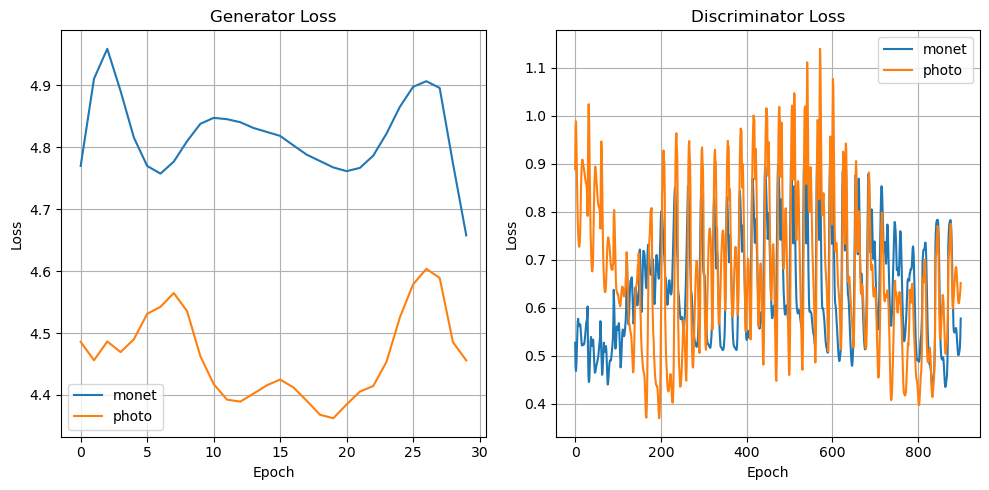

In [8]:
def plot_hist(hist):
    plt.figure(figsize=(10,5))
    plt.subplot(121)
    #plt.plot(np.mean(hist.history['monet_gen_loss'][0][0], axis=1))
    #plt.plot(np.mean(hist.history['photo_gen_loss'][0][0], axis=1))    
    plt.plot(hist.history['monet_gen_loss'][0][0].flatten())
    plt.plot(hist.history['photo_gen_loss'][0][0].flatten())   
    plt.legend(["monet","photo"])
    plt.title('Generator Loss')
    plt.ylabel("Loss")
    plt.xlabel("Epoch")
    plt.grid()
    plt.subplot(122)
    plt.plot(hist.history['monet_disc_loss'][0][0].flatten())
    plt.plot(hist.history['photo_disc_loss'][0][0].flatten())
    plt.title("Discriminator Loss")
    plt.ylabel("Loss")
    plt.xlabel("Epoch")
    plt.grid()
    plt.legend(["monet","photo"])
    plt.tight_layout()
    plt.show()

plot_hist(history)

In [ ]:
! mkdir ../images

def generate(dataset):
    dataset_iter = iter(dataset)
    out_dir = '../images/'
    for i in tqdm.tqdm(range(n_photo_samples)):
        # Get the image from the dataset iterator
        img = next(dataset_iter)
        prediction = model.generate(img)
        prediction = tf.squeeze(prediction).numpy()
        prediction = (prediction * 127.5 + 127.5).astype(np.uint8)   
        plt.imsave(os.path.join(out_dir, 'image_{:04d}.jpg'.format(i)), prediction)

generate(photo_ds)

import shutil
shutil.make_archive("/kaggle/working/images", 'zip', "/kaggle/images")